# Exercise 1.


##### Predicting student exam scores. => Supervised Learning.
##### Clustering customers based on purchase patterns. => Unsupervised Learning.
##### Training an agent to play chess. => Reinforcement Learning.

# Exercise 2.

In [10]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


(a) Perform EDA

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

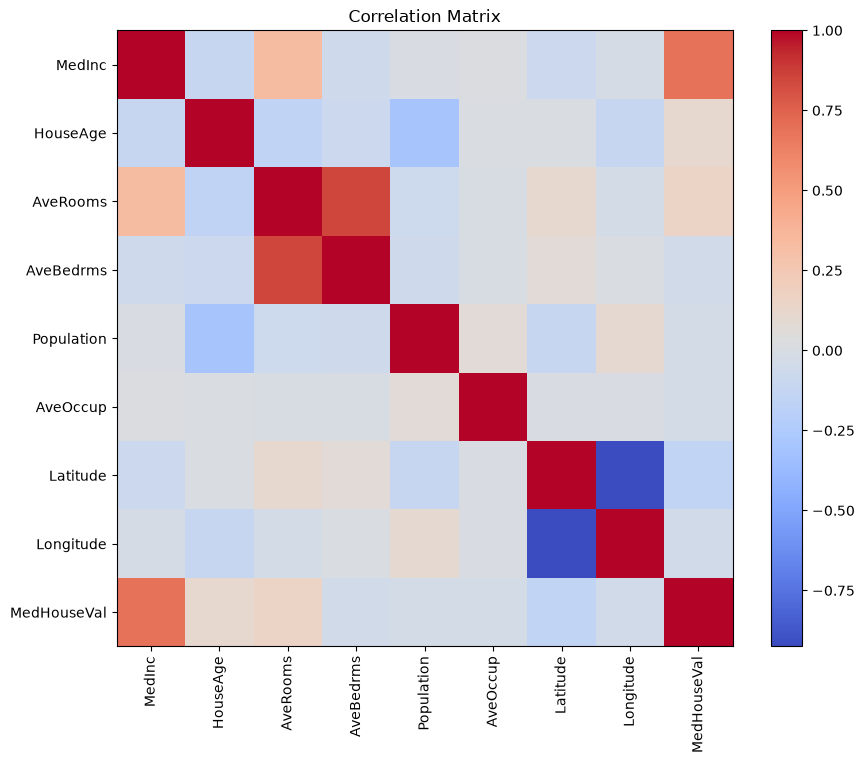

In [11]:
import matplotlib.pyplot as plt
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

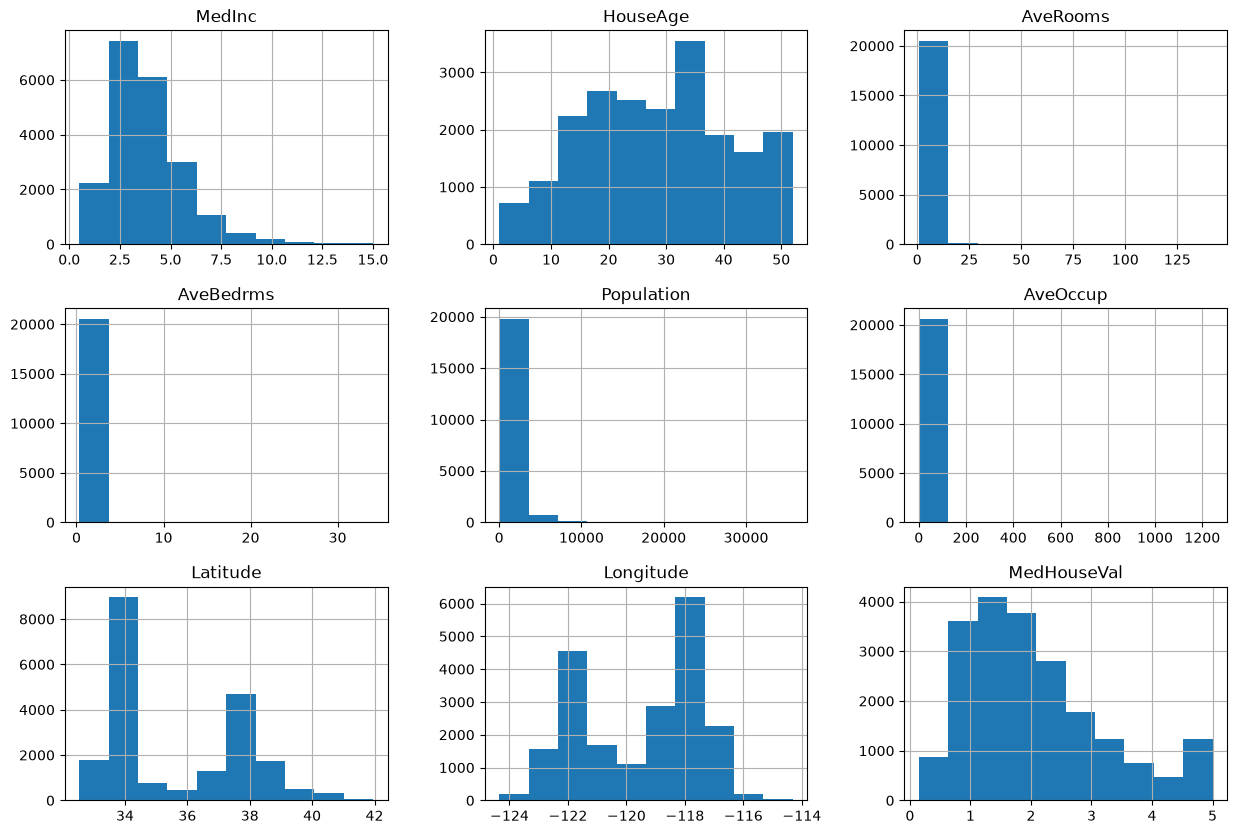

In [14]:
df.hist(figsize=(15,10))
plt.show()

(b) Normalize using MinMaxScaler

In [15]:
from sklearn.preprocessing import MinMaxScaler

X = df.drop("MedHouseVal", axis=1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])

[[0.53966842 0.78431373 0.0435123  0.02046866 0.00894083 0.00149943
  0.5674814  0.21115538]
 [0.53802706 0.39215686 0.03822395 0.01892926 0.0672104  0.00114074
  0.565356   0.21215139]
 [0.46602805 1.         0.05275646 0.02194011 0.01381765 0.00169796
  0.5642933  0.21015936]
 [0.35469856 1.         0.03524099 0.02192864 0.01555537 0.0014933
  0.5642933  0.20916335]
 [0.23077613 1.         0.03853386 0.02216644 0.01575156 0.00119838
  0.5642933  0.20916335]]


(C). Explain how scaling affects the dataset.

Makes optimization easier.

# Exercise 3.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

test_sizes = [0.1,0.3,0.4]

for size in test_sizes:

    X_train,X_test,y_train,y_test = train_test_split(
        X_scaled,
        df["MedHouseVal"],
        test_size=size,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train,y_train)

    score = model.score(X_test,y_test)

    print(f"Test Size = {size} -> R² = {score:.4f}")

Test Size = 0.1 -> R² = 0.5808
Test Size = 0.3 -> R² = 0.5958
Test Size = 0.4 -> R² = 0.5939


# Exercise 4

In [20]:
from sklearn.model_selection import cross_val_score

model = LinearRegression()

scores5 = cross_val_score(
    model,
    X_scaled,
    df["MedHouseVal"],
    cv=5,
    scoring="r2"
)

print("5-Fold Scores")
print(scores5)
print("Average:", scores5.mean())

print()

5-Fold Scores
[0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Average: 0.5530311140279573



In [21]:
scores10 = cross_val_score(
    model,
    X_scaled,
    df["MedHouseVal"],
    cv=10,
    scoring="r2"
)

print("10-Fold Scores")
print(scores10)
print("Average:", scores10.mean())


10-Fold Scores
[0.48254494 0.61416063 0.42274892 0.48178521 0.55705986 0.5412919
 0.47496038 0.45844938 0.48177943 0.59528796]
Average: 0.5110068610524537
